# Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df=pd.read_csv("processed_logs.csv")
df.head()

,LineId,Date,Time,Pid,Level,Component,EventId,timestamp,hour,content_length,template_length,level_encoded,component_encoded,event_encoded
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,E10,2008-11-09 20:36:15,20,61,49,0,3,1
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,E10,2008-11-09 20:38:07,20,64,49,0,3,1
2,3,81109,204005,35,INFO,dfs.FSNamesystem,E6,2008-11-09 20:40:05,20,121,88,0,5,10
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,E10,2008-11-09 20:40:15,20,63,49,0,3,1
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,E10,2008-11-09 20:41:06,20,64,49,0,3,1


In [3]:
print("Shape:",df.shape)
print("\nColumns:\n")
print(df.columns)

Shape: (2000, 14)

Columns:

Index(['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'EventId',
       'timestamp', 'hour', 'content_length', 'template_length',
       'level_encoded', 'component_encoded', 'event_encoded'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   LineId             2000 non-null   int64
 1   Date               2000 non-null   int64
 2   Time               2000 non-null   int64
 3   Pid                2000 non-null   int64
 4   Level              2000 non-null   str  
 5   Component          2000 non-null   str  
 6   EventId            2000 non-null   str  
 7   timestamp          2000 non-null   str  
 8   hour               2000 non-null   int64
 9   content_length     2000 non-null   int64
 10  template_length    2000 non-null   int64
 11  level_encoded      2000 non-null   int64
 12  component_encoded  2000 non-null   int64
 13  event_encoded      2000 non-null   int64
dtypes: int64(10), str(4)
memory usage: 309.8 KB


In [5]:
df.isnull().sum()

LineId               0
Date                 0
Time                 0
Pid                  0
Level                0
Component            0
EventId              0
timestamp            0
hour                 0
content_length       0
template_length      0
level_encoded        0
component_encoded    0
event_encoded        0
dtype: int64

## Log Level Distribution

In [6]:
df["Level"].value_counts()

Level
INFO    1920
WARN      80
Name: count, dtype: int64

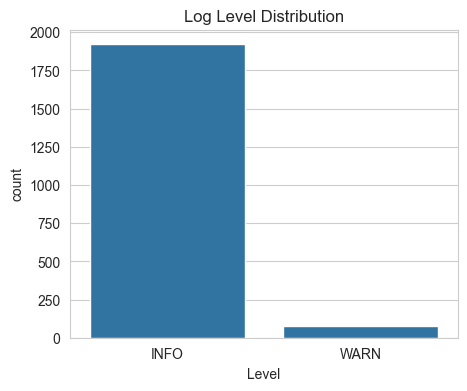

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["Level"])
plt.title("Log Level Distribution")
plt.show()

## Top Components

In [8]:
top_components=(df["Component"].value_counts().head(10))
top_components

Component
dfs.FSNamesystem                659
dfs.DataNode$PacketResponder    603
dfs.DataNode$DataXceiver        454
dfs.FSDataset                   263
dfs.DataBlockScanner             20
dfs.DataNode                      1
Name: count, dtype: int64

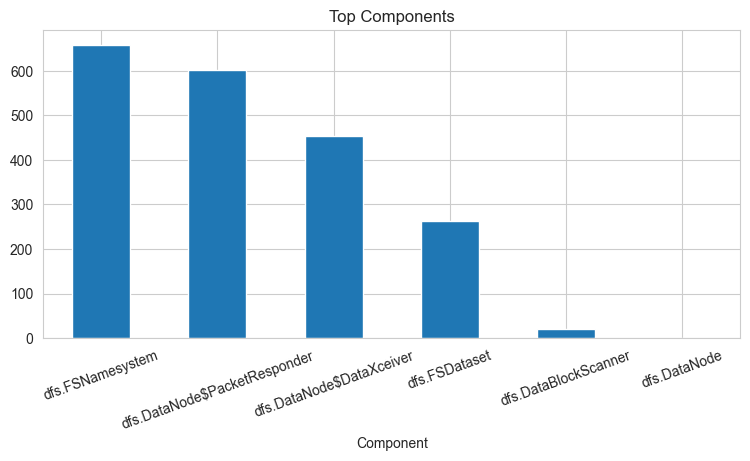

In [9]:
plt.figure(figsize=(9,4))
top_components.plot(kind="bar")
plt.title("Top Components")
plt.xticks(rotation=20)
plt.show()

## Event Frequency

In [10]:
events=(df["EventId"].value_counts().head(15))
events

EventId
E6     314
E10    311
E11    292
E13    292
E9     263
E8     224
E7     115
E1      80
E3      80
E14     20
E4       5
E12      2
E2       1
E5       1
Name: count, dtype: int64

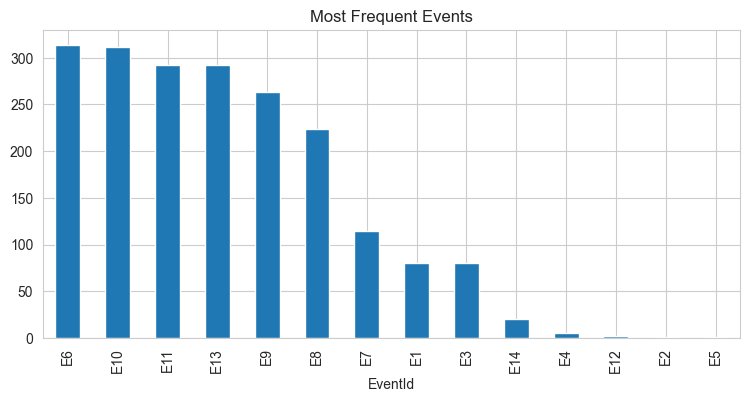

In [11]:
plt.figure(figsize=(9,4))
events.plot(kind="bar")
plt.title("Most Frequent Events")
plt.show()

## Content Length Distribution

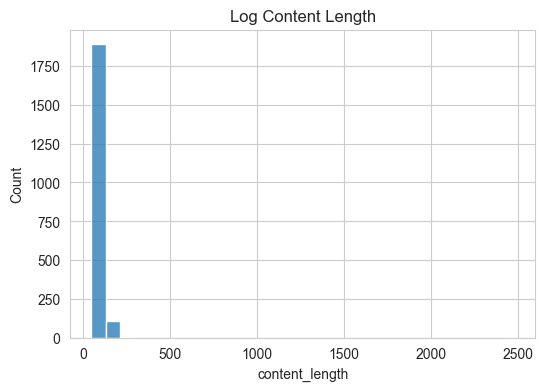

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["content_length"],bins=30)
plt.title("Log Content Length")
plt.show()

## Event Template Length

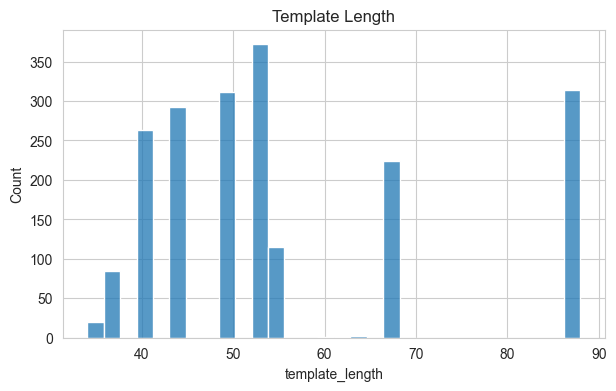

In [13]:
plt.figure(figsize=(7,4))
sns.histplot(df["template_length"],bins=30)
plt.title("Template Length")
plt.show()

## Correlation Matrix

In [14]:
features=["content_length","template_length","level_encoded","component_encoded","event_encoded"]
corr=df[features].corr()
corr

,content_length,template_length,level_encoded,component_encoded,event_encoded
content_length,1.000000,0.126833,-0.013929,0.223491,0.225496
template_length,0.126833,1.000000,-0.043632,0.644243,0.408547
level_encoded,-0.013929,-0.043632,1.000000,-0.256708,0.015207
component_encoded,0.223491,0.644243,-0.256708,1.000000,0.744797
event_encoded,0.225496,0.408547,0.015207,0.744797,1.000000


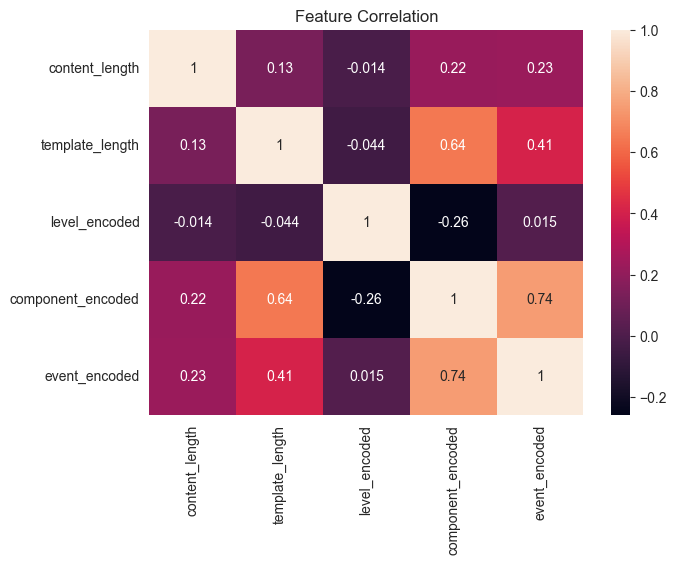

In [15]:
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True)
plt.title("Feature Correlation")
plt.show()

In [16]:
print("===== SYSTEM INSIGHTS =====")
print("Total Logs:",len(df))
print("Unique Events:",df["EventId"].nunique())
print("Components:",df["Component"].nunique())
print("Top Component:",df["Component"].value_counts().index[0])

===== SYSTEM INSIGHTS =====
Total Logs: 2000
Unique Events: 14
Components: 6
Top Component: dfs.FSNamesystem


## save eda summary

In [17]:
eda_summary={
"rows":len(df),
"events":df["EventId"].nunique(),
"components":df["Component"].nunique()
}
print(eda_summary)

{'rows': 2000, 'events': 14, 'components': 6}
